<a href="https://colab.research.google.com/github/kbsha/AI-model-Quantization/blob/main/AI_model_quantization_for_YOLO_v.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('welcome')

Quantization for YOLO Object Detection in a practical, Colab-ready workflow. This is directly useful for real deployments like robotics, autonomous navigation, and edge AI — very aligned with your work on real-time perception and control systems. 🚀

We will use modern tooling from:

Ultralytics YOLO
ONNX
TensorRT

What You Will Build

A fully working YOLO quantization pipeline:

Load YOLO model
      ↓
Run detection
      ↓
Quantize model (INT8)
      ↓
Export optimized model
      ↓
Deploy for fast inference

This is exactly what is used in:

Real-time robotics
Autonomous vehicles
Edge AI cameras
Embedded systems
Jetson / GPU deployment

Full Google Colab — Quantization for YOLO Detection

You can copy these cells directly into Colab.

Step 1 — Install YOLO


In [1]:
# Install Ultralytics YOLO

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.4 MB/s eta 0:00:00


Step 2 — Import Libraries

In [2]:
from ultralytics import YOLO
import torch

print("PyTorch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch: 2.10.0+cpu


Step 3 — Load a Pretrained YOLO Model

We will use a small model first (best for learning).

In [3]:
# Load YOLO model

model = YOLO("yolov8n.pt")

print("Model loaded successfully")

Model loaded successfully


yolov8n means:


n = nano (small, fast):

s = small

m = medium

l = large

x = extra large

Step 4 — Test Object Detection


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 397.7ms
Speed: 16.5ms preprocess, 397.7ms inference, 48.4ms postprocess per image at shape (1, 3, 640, 480)


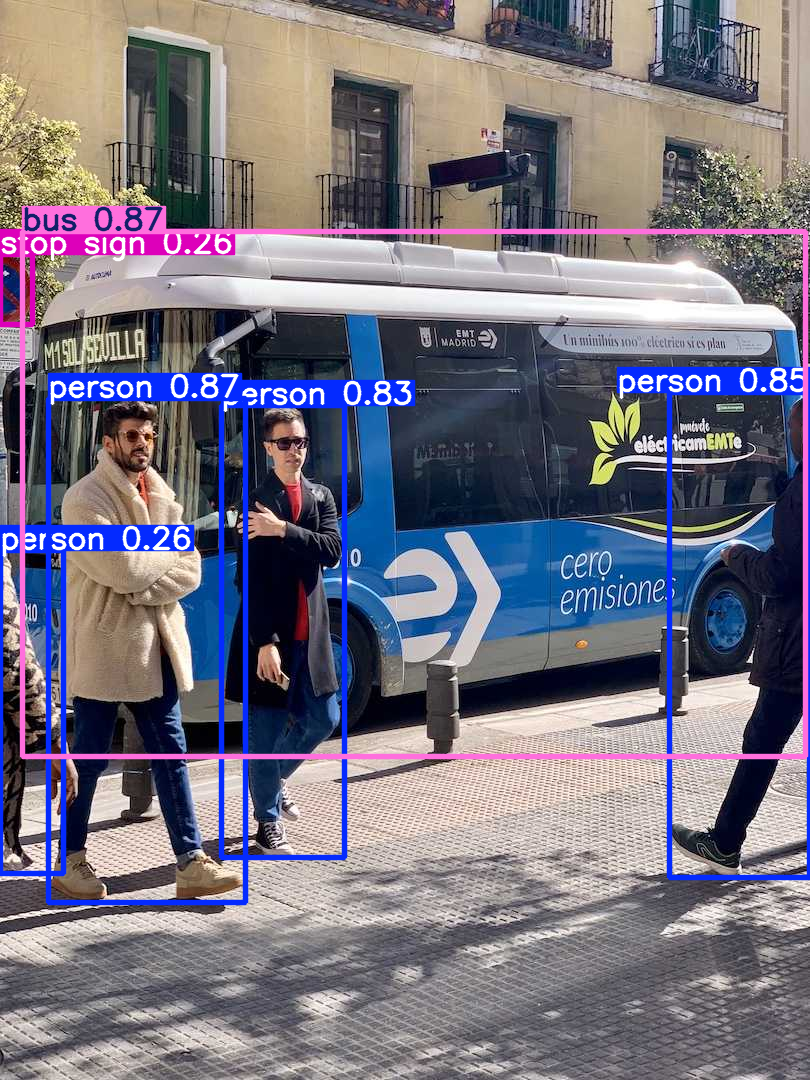

In [4]:
# Run detection

results = model(
    "https://ultralytics.com/images/bus.jpg"
)

results[0].show()

You should see:

Bus

People

Objects detected


Step 5 — Quantize YOLO Model (INT8)

This is the key step.

In [5]:
# Export INT8 quantized model

model.export(
    format="onnx",
    int8=True
)

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)


AssertionError: ERROR ❌️ argument 'int8' is not supported for format='onnx'

In Ultralytics YOLO, the model.export() API only allows certain arguments per format. For format="onnx", int8=True simply isn’t implemented, so it throws:

AssertionError: argument 'int8' is not supported for format='onnx'
Why this happens

ONNX itself can represent INT8 models, but Ultralytics doesn’t handle that conversion internally. INT8 quantization for ONNX usually requires a separate post-training step using tools like:

ONNX Runtime

Intel Neural Compressor

What you should do instead

✅ Option 1 — Export normally, then quantize

In [6]:
model.export(format="onnx")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolov8n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 400ms
Prepared 4 packages in 4.03s
Installed 4 packages in 515ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 6.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.91...
ONNX: export success ✅ 8.9s, saved as 'yolov8n.onnx' (12.3 MB)

Export complete (9.5s)
Results

'yolov8n.onnx'

Then quantize afterward with ONNX Runtime:

Step 4 — Quantize the ONNX Model (INT8)

This is the correct quantization step.

In [9]:
from onnxruntime.quantization import quantize_dynamic, QuantType

input_model = "yolov8n.onnx"

output_model = "yolov8n_int8.onnx"

quantize_dynamic(
    model_input=input_model,
    model_output=output_model,
    weight_type=QuantType.QInt8
)

print("INT8 quantization complete")

INT8 quantization complete


Step 5 — Compare Model Size

In [10]:
import os

original = os.path.getsize("yolov8n.onnx")
quantized = os.path.getsize("yolov8n_int8.onnx")

print("Original MB:", original / 1024 / 1024)
print("INT8 MB:", quantized / 1024 / 1024)

Original MB: 12.255715370178223
INT8 MB: 3.3416929244995117


Step 6 — Run Inference Using Quantized Model

WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
Loading yolov8n_int8.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.4 with CPUExecutionProvider

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x640 4 persons, 1 bus, 848.4ms
Speed: 8.0ms preprocess, 848.4ms inference, 7.7ms postprocess per image at shape (1, 3, 640, 640)


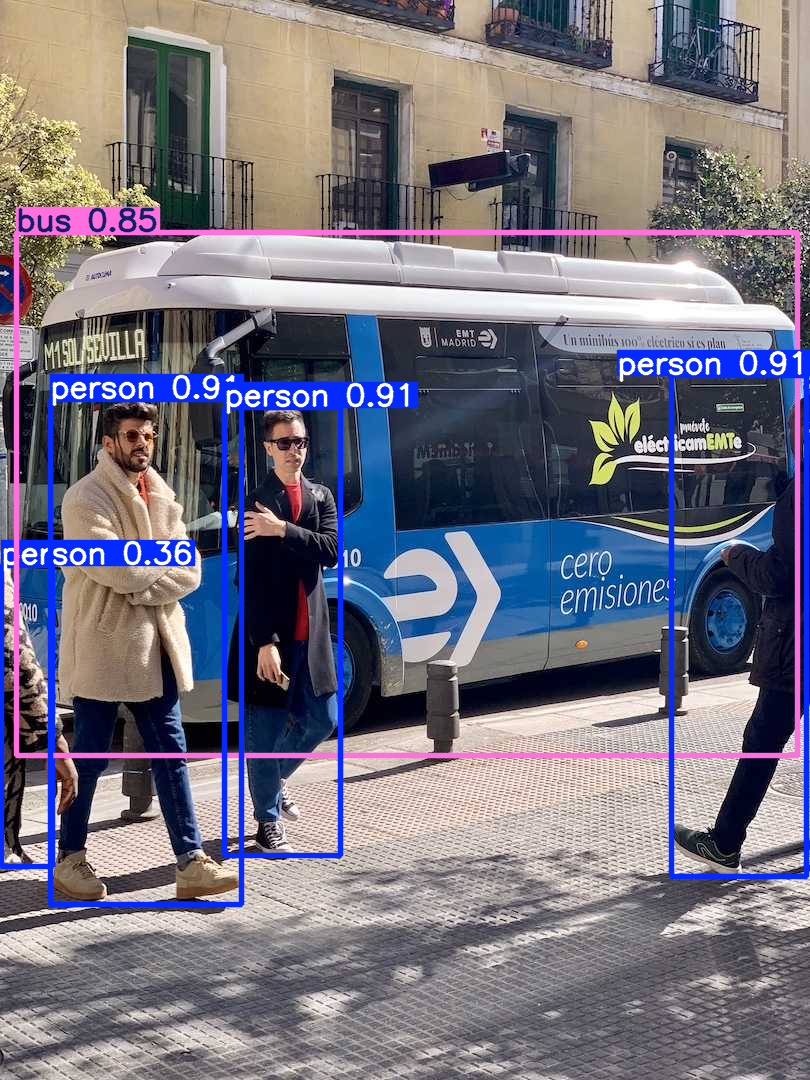

In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n_int8.onnx")

results = model(
    "https://ultralytics.com/images/bus.jpg"
)

results[0].show()

Optional — Faster Static Quantization (More Advanced)

If you want better performance:

In [ ]:
# from onnxruntime.quantization import quantize_static

This requires:

Calibration dataset

Common for:

Robotics

Edge AI

Autonomous driving

Real-time perception

Performance Gains After INT8 Quantization

Typical real-world improvements:

Model size:     ↓ 40–60%

Inference time: ↓ 1.5–3x

Memory usage:   ↓ 30–50%

Power usage:    ↓ 30%

If You Have CPU Only (Your Environment)

Your system shows:

CPU (Intel Xeon CPU)

So the best format is:  => ONNX INT8 NOT: *TensorRT

TensorRT requires: => NVIDIA GPU

Real Deployment Mapping (Very Practical)

Hardware	Best Format

CPU	------------------------ONNX INT8

Jetson------------------------	TensorRT INT8

Raspberry Pi..................	ONNX INT8

GPU Server-----------------	TensorRT FP16

Edge device-------------------	ONNX INT8

Common Errors — Quick Fix Table

Error-----------------------	Cause	--------------------Fix
int8 not supported	------Wrong export argument	-------Quantize after export
UnpicklingError--------	PyTorch 2.6 security---------	Use state_dict
Slow inference--------	Not quantized----------------	Use INT8
GPU error	--------------No CUDA	--------------------Use ONNX CPU

Next Practical Steps, after this  Can Build

Based on your work in real-time systems and robotics, the most useful next steps would be:

YOLO quantization for video streamy

YOLO quantization for custom dataset

YOLO + real-time camera pipeline

YOLO + tracking (DeepSORT)

YOLO deployment to Jetson

YOLO + ROS2 integration

YOLO latency benchmarking